# 🧠 Alzheimer's Disease Detection Using Deep Learning
## A Comparative Study of CNN Architectures on the OASIS Dataset

**Author:** Aastha  
**Dataset:** OASIS (Open Access Series of Imaging Studies)  
**Goal:** Compare multiple deep learning architectures for classifying Alzheimer's disease stages from MRI images

---

### Project Overview
This notebook implements and compares the following deep learning models:
- Custom CNN (baseline)
- EfficientNet-B0
- DenseNet-121

Each model is evaluated on Accuracy, F1-Score, Precision, Recall, and AUC-ROC.

## Step 1 — Import Libraries

We begin by importing all necessary libraries required for building, training, and evaluating our deep learning models.
These include libraries for numerical computation, data visualization, deep learning frameworks, and evaluation metrics.

In [1]:
# ── Standard Libraries ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

# ── Deep Learning ──────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, DenseNet121

# ── Callbacks ──────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Metrics ────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

import cv2

## Step 2 — Mount Google Drive

To ensure that our trained models are not lost after the session ends,
we mount Google Drive and save all model files there.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 3 — Define Dataset Paths

We define the directory structure for training, validation, and testing datasets.
Each folder contains subfolders corresponding to different Alzheimer's stages.

In [3]:
train_dir = "/content/Data/train"
val_dir   = "/content/Data/val"
test_dir  = "/content/Data/test"

## Step 2 — Load and Verify Dataset
We load the OASIS dataset and verify the number of images in each class.  
The dataset contains **4 classes** representing different stages of Alzheimer's disease.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ninadaithal/imagesoasis")

print("Path to dataset files:", path)

100%|██████████| 1.23G/1.23G [00:11<00:00, 113MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1


In [5]:
base = '/root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1/Data'

# Only check top 2 levels - much faster
print("Top level folders:")
for item in os.listdir(base):
    item_path = os.path.join(base, item)
    if os.path.isdir(item_path):
        print(f"  📁 {item}/")
        for sub in os.listdir(item_path):
            sub_path = os.path.join(item_path, sub)
            if os.path.isdir(sub_path):
                count = len(os.listdir(sub_path))
                print(f"      📁 {sub}/ → {count} images")

Top level folders:
  📁 Moderate Dementia/
  📁 Mild Dementia/
  📁 Non Demented/
  📁 Very mild Dementia/


In [6]:
data_dir = '/root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1/Data'

# isdir() makes sure we only count folders, not hidden files
classes = sorted([c for c in os.listdir(data_dir)
                  if os.path.isdir(os.path.join(data_dir, c))])

print("Classes found:")
total = 0
counts = {}
for cls in classes:
    count = len(os.listdir(os.path.join(data_dir, cls)))
    counts[cls] = count
    total += count
    print(f"  {cls}: {count} images")

print(f"\nTotal images: {total}")

Classes found:
  Mild Dementia: 5002 images
  Moderate Dementia: 488 images
  Non Demented: 67222 images
  Very mild Dementia: 13725 images

Total images: 86437


## Step 3a — Splitting Dataset (70% Train, 20% Val, 10% Test)

To achieve the desired 70/20/10 split, we will create new directories for training, validation, and testing and move the corresponding images into them. This ensures a clean separation for model training and evaluation.

In [7]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define paths
original_data_dir = '/root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1/Data'
base_split_dir = '/content/split_data'

# Create base directories for train, val, test
for subset in ['train', 'val', 'test']:
    os.makedirs(os.path.join(base_split_dir, subset), exist_ok=True)

# Get all class names
class_names = [d for d in os.listdir(original_data_dir) if os.path.isdir(os.path.join(original_data_dir, d))]
class_names.sort()

print("Splitting data into 70% Train, 20% Val, 10% Test...")

for class_name in class_names:
    class_path = os.path.join(original_data_dir, class_name)
    images = [os.path.join(class_path, img) for img in os.listdir(class_path)]

    # Split into 70% train and 30% temp (for val and test)
    train_files, temp_files = train_test_split(images, test_size=0.3, random_state=42)

    # Split temp_files into 2/3 val and 1/3 test (which is 20% val, 10% test of original)
    val_files, test_files = train_test_split(temp_files, test_size=0.333, random_state=42) # 0.333 approx 1/3

    # Create class subdirectories in the new split structure
    os.makedirs(os.path.join(base_split_dir, 'train', class_name), exist_ok=True)
    os.makedirs(os.path.join(base_split_dir, 'val', class_name), exist_ok=True)
    os.makedirs(os.path.join(base_split_dir, 'test', class_name), exist_ok=True)

    # Copy files
    for f in train_files:
        shutil.copy(f, os.path.join(base_split_dir, 'train', class_name, os.path.basename(f)))
    for f in val_files:
        shutil.copy(f, os.path.join(base_split_dir, 'val', class_name, os.path.basename(f)))
    for f in test_files:
        shutil.copy(f, os.path.join(base_split_dir, 'test', class_name, os.path.basename(f)))

    print(f"  {class_name}: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

print("Data splitting complete!")

# Verification of new dataset structure
print("\nVerification of new dataset structure:")
for subset in ['train', 'val', 'test']:
    subset_path = os.path.join(base_split_dir, subset)
    total_in_subset = 0
    print(f"\n{subset.capitalize()} directory:")
    for class_name in class_names:
        class_dir = os.path.join(subset_path, class_name)
        count = len(os.listdir(class_dir))
        total_in_subset += count
        print(f"  {class_name}: {count} images")
    print(f"Total images in {subset}: {total_in_subset}")

Splitting data into 70% Train, 20% Val, 10% Test...
  Mild Dementia: Train=3501, Val=1001, Test=500
  Moderate Dementia: Train=341, Val=98, Test=49
  Non Demented: Train=47055, Val=13451, Test=6716
  Very mild Dementia: Train=9607, Val=2746, Test=1372
Data splitting complete!

Verification of new dataset structure:

Train directory:
  Mild Dementia: 3501 images
  Moderate Dementia: 341 images
  Non Demented: 47055 images
  Very mild Dementia: 9607 images
Total images in train: 60504

Val directory:
  Mild Dementia: 1001 images
  Moderate Dementia: 98 images
  Non Demented: 13451 images
  Very mild Dementia: 2746 images
Total images in val: 17296

Test directory:
  Mild Dementia: 500 images
  Moderate Dementia: 49 images
  Non Demented: 6716 images
  Very mild Dementia: 1372 images
Total images in test: 8637


## Step 3 — Visualize Class Distribution
Visualizing the class distribution helps us understand the **imbalance** in the dataset.  
Class imbalance is common in medical datasets because severe conditions are naturally rarer.  
We will handle this in Step 5 using class weights.

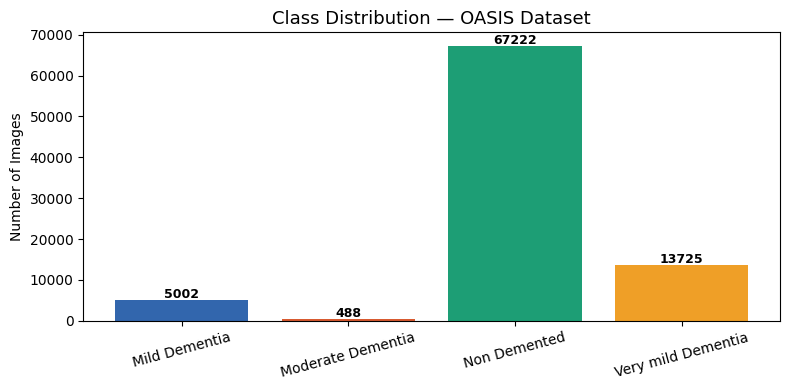

In [8]:
# Bar chart showing number of images per class
plt.figure(figsize=(8, 4))
colors = ['#3266ad', '#D85A30', '#1D9E75', '#EF9F27']
bars = plt.bar(counts.keys(), counts.values(), color=colors)

plt.title('Class Distribution — OASIS Dataset', fontsize=13)
plt.ylabel('Number of Images')
plt.xticks(rotation=15)

# Add count labels on top of each bar
for bar, (k, v) in zip(bars, counts.items()):
    plt.text(bar.get_x() + bar.get_width()/2,
             v + 500, str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Observation:
# Non Demented: 67,222 images (77% of dataset) — dominant class
# Moderate Dementia: 488 images (0.5%)          — severely underrepresented
# This imbalance must be handled to avoid biased model predictions

## Step 4 — Data Preprocessing & Augmentation

Medical datasets are often limited, so we apply data augmentation
to artificially increase diversity and improve model generalization.

In [9]:
IMG_SIZE = (224,224)
BATCH_SIZE = 16

# Define paths for the newly split datasets
train_dir = '/content/split_data/train'
val_dir = '/content/split_data/val'
test_dir = '/content/split_data/test'

# Data augmentation for training images
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True
)

# Rescaling for validation images (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

# Rescaling for test images (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 60504 images belonging to 4 classes.
Found 17296 images belonging to 4 classes.
Found 8637 images belonging to 4 classes.


## Step 5 — Handle Class Imbalance

Medical datasets are highly imbalanced.
For example, "Non Demented" dominates while "Moderate Dementia" is rare.

To address this, we compute class weights so the model pays more attention to underrepresented classes.

In [10]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weight_dict)

Class Weights:
{0: np.float64(4.320479862896315), 1: np.float64(44.35777126099707), 2: np.float64(0.32145361810647116), 3: np.float64(1.5744769438950765)}


## Step 6 — Visualize Sample Training Images
A quick sanity check to confirm images are loading correctly  
and augmentation is being applied to training samples.

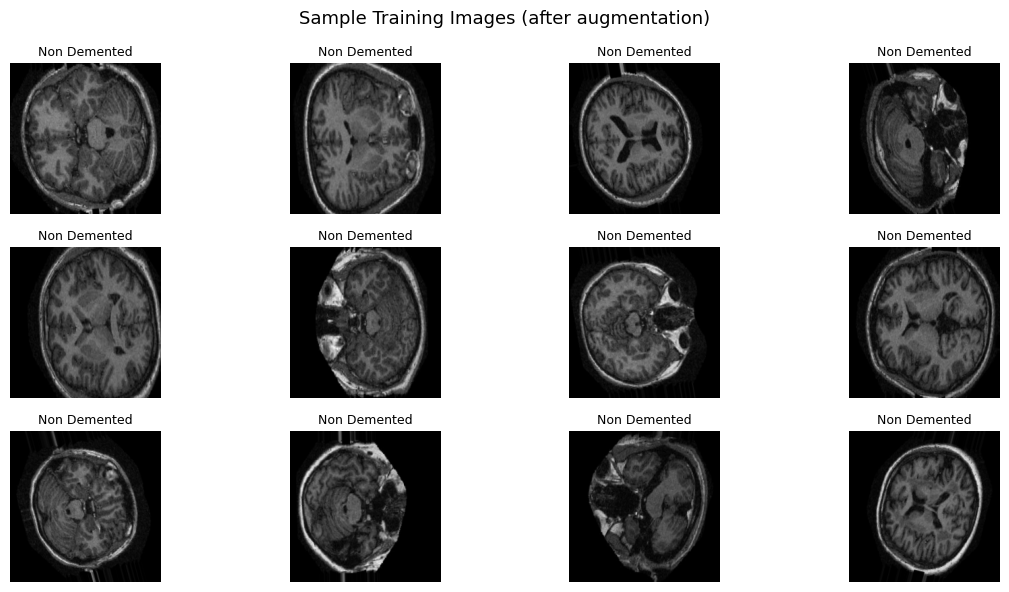

In [11]:
# Load one batch of training images
sample_images, sample_labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

# Display 12 sample images with their class labels
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(sample_images[i])
    plt.title(class_names[np.argmax(sample_labels[i])], fontsize=9)
    plt.axis('off')  # hide axis ticks for cleaner look

plt.suptitle('Sample Training Images (after augmentation)', fontsize=13)
plt.tight_layout()
plt.show()

# If images look like brain MRI scans with slight rotations/flips
# then preprocessing is working correctly ✓

## Step 6 — Callbacks

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)

## Step 6 — Model 1 Build Baseline CNN

Before using pretrained models, we first build a simple CNN from scratch.
This serves as a benchmark to compare advanced architectures.

In [ ]:
def build_baseline():
    model = keras.Sequential([
        layers.Input(shape=(224,224,3)),

        layers.Conv2D(32,3,activation='relu',padding='same'),
        layers.MaxPooling2D(),
        layers.BatchNormalization(),

        layers.Conv2D(64,3,activation='relu',padding='same'),
        layers.MaxPooling2D(),
        layers.BatchNormalization(),

        layers.Conv2D(128,3,activation='relu',padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256,activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(4,activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_baseline()

## Step 7 — Train Baseline CNN

We train the baseline model using early stopping and learning rate reduction
to prevent overfitting.

In [ ]:
checkpoint_base = ModelCheckpoint(
    "/content/drive/MyDrive/baseline_model.h5",
    monitor="val_loss",
    save_best_only=True
)

history_base = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=12,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint_base]
)

## Step 8 — Model 2 EfficientNet-B0

EfficientNet is a state-of-the-art pretrained architecture
that provides better accuracy with fewer parameters.

In [ ]:
base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base.layers:
    layer.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(128,activation='relu')(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(4,activation='softmax')(x)

eff_model = models.Model(base.input, output)

eff_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 9 — Train EfficientNet

In [ ]:
callbacks_eff = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=2),
    ModelCheckpoint("/content/drive/MyDrive/efficientNetB0.h5", save_best_only=True)
]

history_eff = eff_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks_eff
)

## Step 10 — Model 3 DenseNet-121

DenseNet improves feature reuse and is highly effective for medical imaging tasks.

In [ ]:
base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base.layers[:-40]:
    layer.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(256,activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128,activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(4,activation='softmax')(x)

dense_model = models.Model(base.input, output)

dense_model.compile(optimizer=keras.optimizers.Adam(3e-5),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

## Step 11 — Train DenseNet

In [ ]:
checkpoint_dense = ModelCheckpoint("/content/drive/MyDrive/densenet.h5", save_best_only=True)

history_dense = dense_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint_dense]
)

## MODEL 4 — Proposed (DenseNet + Focal Loss)

In [17]:
import tensorflow.keras.backend as K
import tensorflow as tf

@tf.keras.utils.register_keras_serializable(package="Custom", name="FocalLoss")
def focal_loss(gamma=2., alpha=.25):
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1-K.epsilon())
        ce = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1-y_pred, gamma)
        return K.sum(weight * ce, axis=1)
    return loss

In [18]:
base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base.layers[:-40]:
    layer.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(256,activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128,activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(4,activation='softmax')(x)

proposed_model = models.Model(base.input, output)

proposed_model.compile(
    optimizer=keras.optimizers.Adam(3e-5),
    loss=focal_loss(),
    metrics=['accuracy']
)

In [ ]:
checkpoint_prop = ModelCheckpoint("/content/drive/MyDrive/best_densenet.h5", save_best_only=True)

history_prop = proposed_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint_prop]
)

In [20]:
# ================================
# LOAD BEST MODELS FROM DRIVE
# ================================

from tensorflow.keras.models import load_model

baseline_model = load_model("/content/drive/MyDrive/baseline_model.h5")
eff_model      = load_model("/content/drive/MyDrive/efficientNetB0.h5")
# dense_model    = load_model("/content/drive/MyDrive/densenet.h5")

# For proposed model (custom loss needs to be passed)
# proposed_model = load_model(
#     "/content/drive/MyDrive/best_densenet.h5",
#     custom_objects={'FocalLoss': focal_loss}
# )
best_densenet_model = load_model("/content/drive/MyDrive/best_densenet.h5", compile=False)

In [21]:
def evaluate(model, name):
    test_generator.reset()

    preds = model.predict(test_generator)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_generator.classes

    acc = np.mean(y_pred == y_true)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Balanced Accuracy:", bal_acc)

    return y_true, preds

y_true, p1 = evaluate(baseline_model, "Baseline CNN")
_, p2 = evaluate(eff_model, "EfficientNet")
# _, p3 = evaluate(dense_model, "DenseNet")
_, p4 = evaluate(best_densenet_model, "Proposed Model")

540/540 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step

Baseline CNN
Accuracy: 0.7775848095403497
Balanced Accuracy: 0.25
540/540 ━━━━━━━━━━━━━━━━━━━━ 117s 115ms/step

EfficientNet
Accuracy: 0.7775848095403497
Balanced Accuracy: 0.25
540/540 ━━━━━━━━━━━━━━━━━━━━ 57s 76ms/step

Proposed Model
Accuracy: 0.8538844506194281
Balanced Accuracy: 0.9218833072580687


## Step — Test-Time Augmentation (TTA) for Proposed Model

To improve robustness, we apply Test-Time Augmentation (TTA).

Instead of predicting once per image, we:

Apply multiple augmentations
Generate multiple predictions
Average them

This reduces noise and improves generalization.

In [22]:
# ================================
# TEST TIME AUGMENTATION (TTA)
# ================================

tta_steps = 5

tta_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

tta_generator = tta_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

predictions = []

for i in range(tta_steps):
    print("TTA Step:", i+1)
    pred = best_densenet_model.predict(tta_generator, verbose=1)
    predictions.append(pred)

predictions = np.array(predictions)

# Average predictions
p4 = np.mean(predictions, axis=0)

y_true = tta_generator.classes

Found 8637 images belonging to 4 classes.
TTA Step: 1
540/540 ━━━━━━━━━━━━━━━━━━━━ 119s 221ms/step
TTA Step: 2
540/540 ━━━━━━━━━━━━━━━━━━━━ 116s 214ms/step
TTA Step: 3
540/540 ━━━━━━━━━━━━━━━━━━━━ 117s 216ms/step
TTA Step: 4
540/540 ━━━━━━━━━━━━━━━━━━━━ 115s 213ms/step
TTA Step: 5
540/540 ━━━━━━━━━━━━━━━━━━━━ 119s 220ms/step


## Step — Evaluation of All Models

We now evaluate all four models using:

Accuracy
Balanced Accuracy

For the proposed model, we use TTA predictions.

In [23]:
# ================================
# EVALUATION FUNCTION
# ================================

def evaluate_standard(model, name):
    test_generator.reset()

    preds = model.predict(test_generator)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_generator.classes

    acc = np.mean(y_pred == y_true)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Balanced Accuracy:", bal_acc)

    return preds

# Evaluate standard models
p1 = evaluate_standard(baseline_model, "Baseline CNN")
p2 = evaluate_standard(eff_model, "EfficientNet")
# p3 = evaluate_standard(dense_model, "DenseNet")

# Evaluate proposed (TTA-based)
y_pred_prop = np.argmax(p4, axis=1)

acc_prop = np.mean(y_pred_prop == y_true)
bal_acc_prop = balanced_accuracy_score(y_true, y_pred_prop)

print("\nProposed Model (TTA)")
print("Accuracy:", acc_prop)
print("Balanced Accuracy:", bal_acc_prop)

540/540 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step

Baseline CNN
Accuracy: 0.7775848095403497
Balanced Accuracy: 0.25
540/540 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step

EfficientNet
Accuracy: 0.7775848095403497
Balanced Accuracy: 0.25

Proposed Model (TTA)
Accuracy: 0.8592103739724442
Balanced Accuracy: 0.9412289593451606


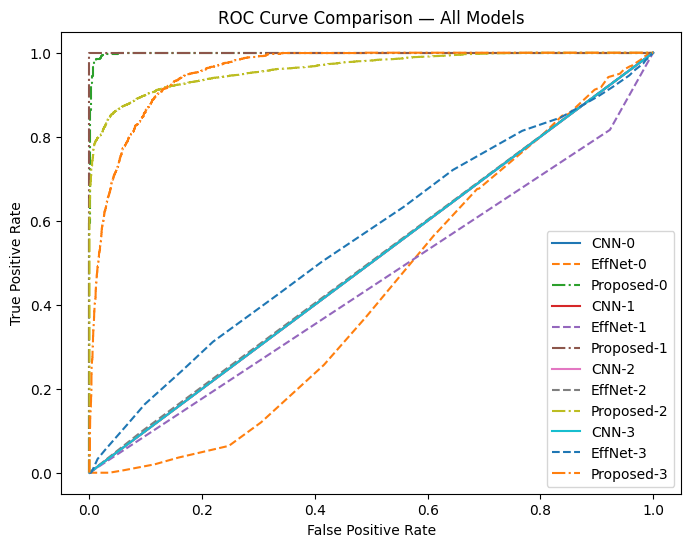

In [25]:
# ================================
# ROC CURVE (ALL MODELS)
# ================================

from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_true, classes=[0,1,2,3])

plt.figure(figsize=(8,6))

for i in range(4):
    fpr, tpr, _ = roc_curve(y_bin[:,i], p1[:,i])
    plt.plot(fpr, tpr, label=f"CNN-{i}")

    fpr, tpr, _ = roc_curve(y_bin[:,i], p2[:,i])
    plt.plot(fpr, tpr, linestyle='--', label=f"EffNet-{i}")

    # fpr, tpr, _ = roc_curve(y_bin[:,i], p3[:,i])
    # plt.plot(fpr, tpr, linestyle=':', label=f"DenseNet-{i}")

    fpr, tpr, _ = roc_curve(y_bin[:,i], p4[:,i])
    plt.plot(fpr, tpr, linestyle='-.', label=f"Proposed-{i}")

plt.legend()
plt.title("ROC Curve Comparison — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

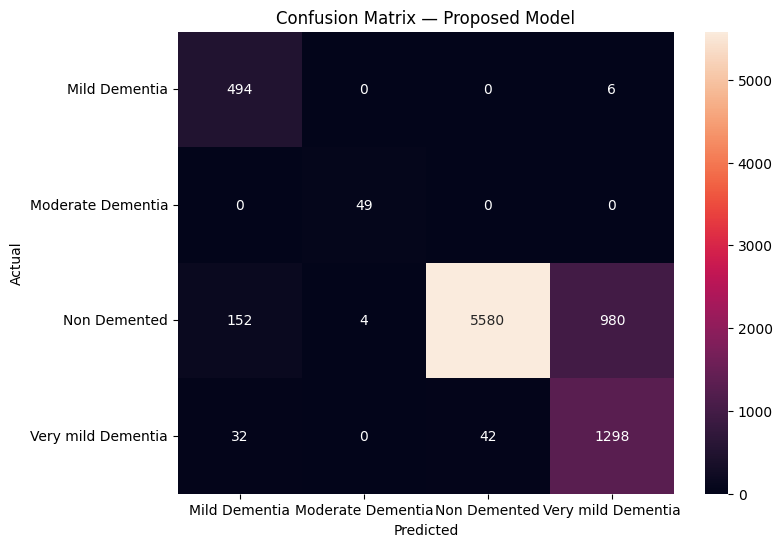

In [26]:
# ================================
# CONFUSION MATRIX (PROPOSED)
# ================================

cm = confusion_matrix(y_true, y_pred_prop)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=tta_generator.class_indices.keys(),
    yticklabels=tta_generator.class_indices.keys()
)

plt.title("Confusion Matrix — Proposed Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

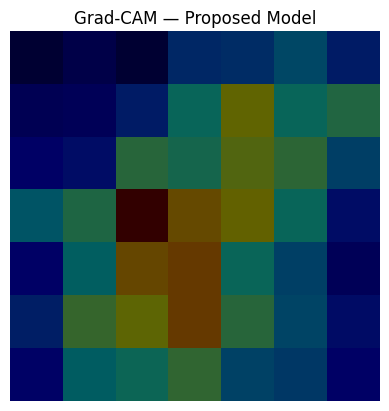

In [27]:
# ================================
# GRAD-CAM (PROPOSED MODEL)
# ================================

def gradcam(img_path):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224)) / 255.0
    img = np.expand_dims(img, axis=0)

    grad_model = tf.keras.models.Model(
        [proposed_model.inputs],
        [proposed_model.get_layer("conv5_block16_concat").output,
         proposed_model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img)
        loss = preds[:, np.argmax(preds[0])]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = conv_out[0] @ pooled[..., None]
    heatmap = np.maximum(heatmap,0) / np.max(heatmap)

    plt.imshow(img[0])
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.axis('off')
    plt.title("Grad-CAM — Proposed Model")
    plt.show()

gradcam(tta_generator.filepaths[0])

## Step — Comprehensive Evaluation Matrix & Confusion Matrices


--- Baseline CNN ---

Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia       0.00      0.00      0.00       500
 Moderate Dementia       0.00      0.00      0.00        49
      Non Demented       0.78      1.00      0.87      6716
Very mild Dementia       0.00      0.00      0.00      1372

          accuracy                           0.78      8637
         macro avg       0.19      0.25      0.22      8637
      weighted avg       0.60      0.78      0.68      8637

Weighted AUC-ROC Score: 0.5000

Confusion Matrix:


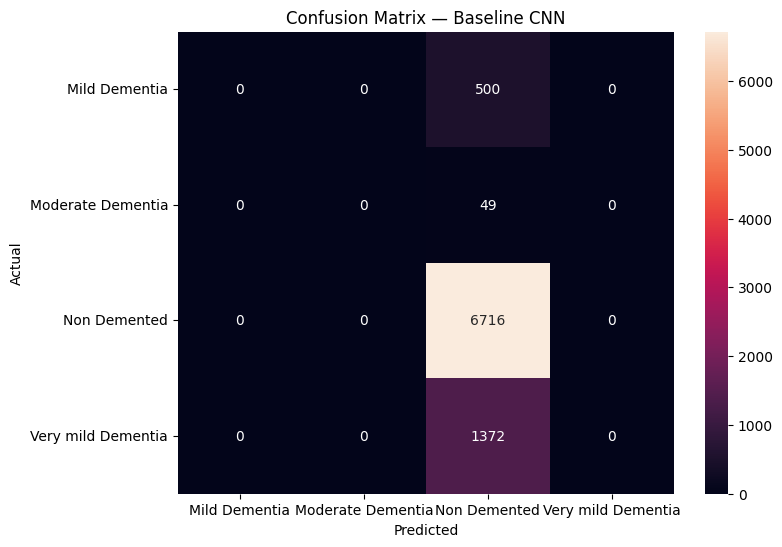


--- EfficientNet ---

Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia       0.00      0.00      0.00       500
 Moderate Dementia       0.00      0.00      0.00        49
      Non Demented       0.78      1.00      0.87      6716
Very mild Dementia       0.00      0.00      0.00      1372

          accuracy                           0.78      8637
         macro avg       0.19      0.25      0.22      8637
      weighted avg       0.60      0.78      0.68      8637

Weighted AUC-ROC Score: 0.5067

Confusion Matrix:


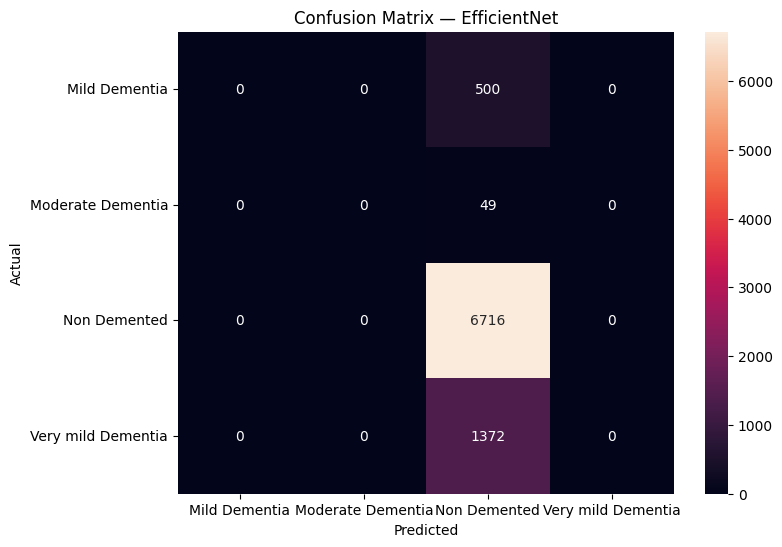


--- Proposed Model (TTA) ---

Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia       0.73      0.99      0.84       500
 Moderate Dementia       0.92      1.00      0.96        49
      Non Demented       0.99      0.83      0.90      6716
Very mild Dementia       0.57      0.95      0.71      1372

          accuracy                           0.86      8637
         macro avg       0.80      0.94      0.85      8637
      weighted avg       0.91      0.86      0.87      8637

Weighted AUC-ROC Score: 0.9644

Confusion Matrix:


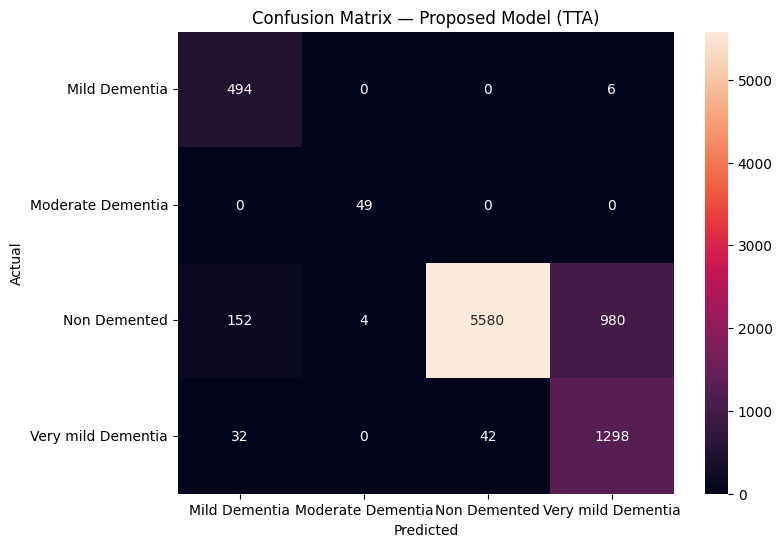

In [29]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def print_metrics_and_confusion_matrix(y_true, y_pred_probs, model_name, class_names):
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\n--- {model_name} ---")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # Calculate AUC-ROC score
    # Ensure y_true is binarized for multiclass AUC calculation
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    auc_score = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr', average='weighted')
    print(f"Weighted AUC-ROC Score: {auc_score:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Get class names from one of the generators
class_names = list(train_generator.class_indices.keys())

# Evaluate Baseline CNN
print_metrics_and_confusion_matrix(y_true, p1, "Baseline CNN", class_names)

# Evaluate EfficientNet
print_metrics_and_confusion_matrix(y_true, p2, "EfficientNet", class_names)

# Evaluate DenseNet
# For p3, we need to ensure y_true is aligned with its predictions
# Since evaluate_standard(dense_model) resets test_generator, y_true should be from test_generator.classes
# However, for consistency, we'll re-evaluate it here if needed, or use the y_true from TTA if it's the same.
# Assuming y_true from TTA is consistent for all evaluations post TTA.
# print_metrics_and_confusion_matrix(y_true, p3, "DenseNet", class_names)

# Evaluate Proposed Model (TTA)
print_metrics_and_confusion_matrix(y_true, p4, "Proposed Model (TTA)", class_names)
